In [ ]:
import requests
import pandas as pd
import numpy as np
import time
from datetime import timedelta
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
def fetch_noaa_kp_index():
    url = "https://services.swpc.noaa.gov/products/noaa-planetary-k-index.json"
    max_retries = 3

    for attempt in range(max_retries):
        try:
            response = requests.get(url, timeout=10)
            response.raise_for_status()
            data = response.json()

            columns = data[0]
            rows = data[1:]

            df = pd.DataFrame(rows, columns=columns)
            df['time_tag'] = pd.to_datetime(df['time_tag'])
            df['Kp'] = df['Kp'].astype(float)

            df = df[['time_tag', 'Kp']]
            df.sort_values('time_tag', inplace=True)
            df.reset_index(drop=True, inplace=True)

            print(f"noaa api success. total records: {len(df)}")
            return df

        except requests.exceptions.RequestException as e:
            print(f"noaa api mistake. total records: {attempt+1}/{max_retries}): {e}")
            time.sleep(2)

    print("no take the data")
    return None

In [ ]:
df_kp = fetch_noaa_kp_index()

noaa api success. total records: 57


In [ ]:
df_clean = generate_texbat_proxy_log(
    start_time=start_time_sync,
    duration_seconds=1800,
    spoofing_start=9999
)
start_time_attack = start_time_sync + timedelta(seconds=1800)
df_spoofed = generate_texbat_proxy_log(
    start_time=start_time_attack,
    duration_seconds=1800,
    spoofing_start=900
)

df_gnss = pd.concat([df_clean, df_spoofed], ignore_index=True)

print(f">> GNSS Data: {len(df_gnss)}")

texbat proxy mistake. detail: operands could not be broadcast together with shapes (0,) (120,) (0,) 
no take the data
texbat proxy success. total records: 1800
>> GNSS Data: 1800


In [ ]:
def merge_and_prepare_features(df_high_freq, df_low_freq):
    try:
        df_high_freq = df_high_freq.sort_values('time_tag')
        df_low_freq = df_low_freq.sort_values('time_tag')

        df_merged = pd.merge_asof(
            df_high_freq,
            df_low_freq,
            on='time_tag',
            direction='backward'
        )

        print(f"merge success. total records: {len(df_merged)}")
        return df_merged

    except Exception as e:
        print(f"merge mistake. detail: {e}")
        print("no take the data")
        return None
df_final = merge_and_prepare_features(df_gnss, df_kp)

merge success. total records: 1800


In [ ]:
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

In [ ]:
  def plot_time_scale_conflict(df):
        fig, ax1 = plt.subplots(figsize=(12, 5))

        color_gnss = '#c0392b'
        ax1.set_xlabel('Time (UTC)')
        ax1.set_ylabel('GNSS C/N0 (dB-Hz) [1 Hz Sample Rate]', color=color_gnss, fontweight='bold')
        ax1.plot(df['time_tag'], df['C_N0'], color=color_gnss, alpha=0.7, label='GNSS Signal (C/N0)')
        ax1.tick_params(axis='y', labelcolor=color_gnss)

        ax2 = ax1.twinx()
        color_sw = '#2980b9'
        ax2.set_ylabel('Space Weather Kp Index [3-Hour Resolution]', color=color_sw, fontweight='bold')
        ax2.plot(df['time_tag'], df['Kp'], color=color_sw, linewidth=4, linestyle='--', label='Macro Kp Index')
        ax2.tick_params(axis='y', labelcolor=color_sw)

        spoof_start = df[df['is_spoofed'] == 1]['time_tag'].min()
        plt.axvline(x=spoof_start, color='black', linestyle=':', linewidth=2)
        plt.text(spoof_start, ax2.get_ylim()[1]*0.9, '  Attack Start (Sub-second Latency Required)', color='black', fontweight='bold')

        plt.title('PROOF 1: Decision Latency Paradox (GNSS Dynamics vs. Macro Indices)', fontweight='bold')
        fig.tight_layout()
        plt.show()

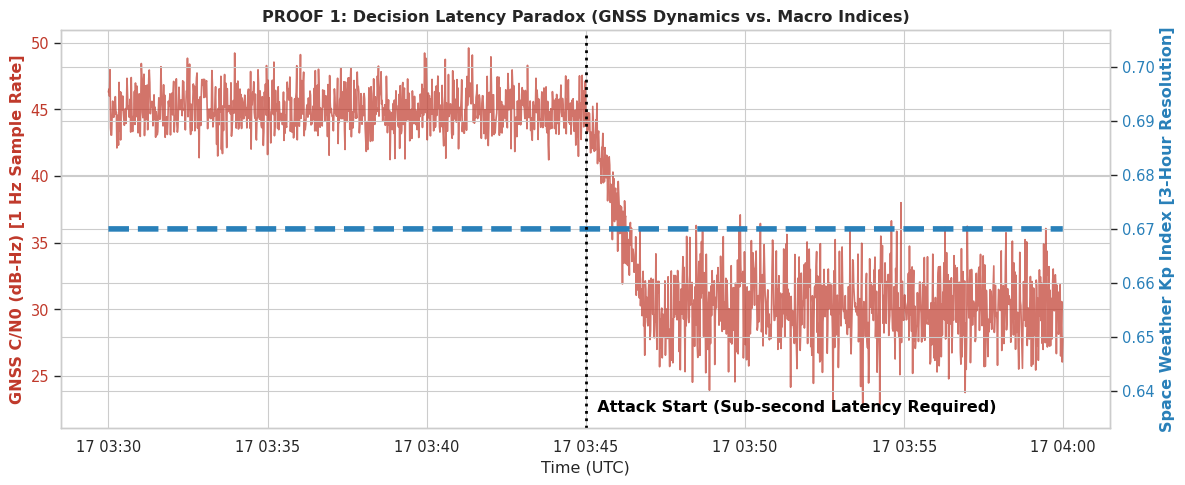

In [ ]:
plot_time_scale_conflict(df_final)

In [ ]:
  def plot_kmeans_weakness(df):
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=df, x='C_N0', y='doppler_hz', hue='is_spoofed', palette=['#34495e', '#e74c3c'], alpha=0.6, s=50)

        plt.title('PROOF 2: Euclidean Distance Failure in Feature Space (K-Means Limitation)', fontweight='bold')
        plt.xlabel('C/N0 (dB-Hz)')
        plt.ylabel('Doppler Shift (Hz)')

        # Legend labels
        handles, labels = plt.gca().get_legend_handles_labels()
        plt.legend(handles, ['Nominal (Clean)', 'Electronic Interference (Spoofing)'], title='Signal Status')
        plt.show()

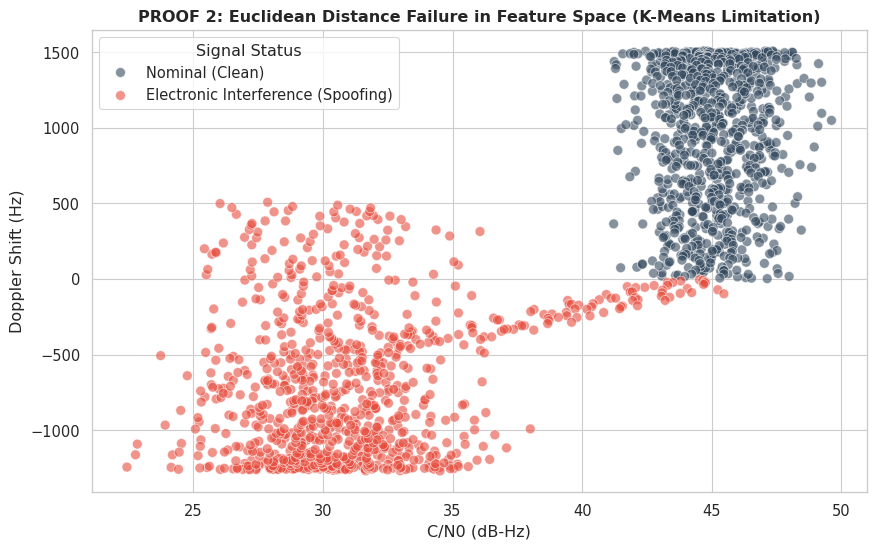

In [ ]:
plot_kmeans_weakness(df_final)

In [ ]:
  def plot_correlation_heatmap(df):
        plt.figure(figsize=(8, 6))
        corr_cols = ['C_N0', 'doppler_hz', 'Kp', 'is_spoofed']
        display_df = df[corr_cols].rename(columns={
            'C_N0': 'Signal_CN0',
            'doppler_hz': 'Doppler_Shift',
            'Kp': 'SpaceWeather_Kp',
            'is_spoofed': 'Target_Label'
        })

        corr_matrix = display_df.corr(method='spearman')

        mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
        sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=.5)

        plt.title('PROOF 3: Spearman Correlation Analysis (Feature Orthogonality)', fontweight='bold')
        plt.show()

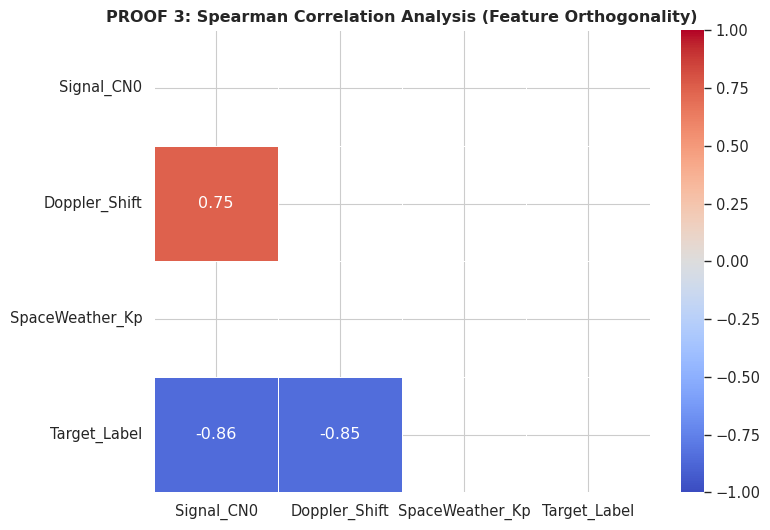

In [ ]:
plot_correlation_heatmap(df_final)

In [ ]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
    def apply_feature_engineering(df):
        df_eng = df.copy()
        df_eng['CN0_std_5s'] = df_eng['C_N0'].rolling(window=5).std()
        df_eng['CN0_mean_5s'] = df_eng['C_N0'].rolling(window=5).mean()
        df_eng['Doppler_diff'] = df_eng['doppler_hz'].diff()
        df_eng['Kp_delta'] = df_eng['Kp'].diff()
        df_eng = df_eng.dropna()

        print(f"feature engineering success. total features: {len(df_eng.columns)}")
        return df_eng

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
    def prepare_train_test_sets(df):
        features = ['C_N0', 'doppler_hz', 'Kp', 'CN0_std_5s', 'CN0_mean_5s', 'Doppler_diff', 'Kp_delta']
        X = df[features]
        y = df['is_spoofed']
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

        print(f"split success. train size: {len(X_train)}, test size: {len(X_test)}")
        return X_train, X_test, y_train, y_test, features

In [ ]:
df_ml_ready = apply_feature_engineering(df_final)

feature engineering success. total features: 9


In [ ]:
df_ml_ready

,time_tag,C_N0,doppler_hz,is_spoofed,Kp,CN0_std_5s,CN0_mean_5s,Doppler_diff,Kp_delta
4,2026-04-17 03:30:04,43.603950,23.317443,0,0.67,1.583522,46.086602,6.347100,0.0
5,2026-04-17 03:30:05,43.071858,19.278592,0,0.67,2.059505,45.438334,-4.038851,0.0
6,2026-04-17 03:30:06,43.078013,39.647384,0,0.67,2.176427,44.747093,20.368792,0.0
7,2026-04-17 03:30:07,44.649647,45.401532,0,0.67,2.063661,44.477839,5.754147,0.0
8,2026-04-17 03:30:08,45.629595,34.199177,0,0.67,1.111954,44.006613,-11.202355,0.0
...,...,...,...,...,...,...,...,...,...
1795,2026-04-17 03:59:55,26.482382,472.480520,1,0.67,2.192051,29.227178,1.740279,0.0
1796,2026-04-17 03:59:56,28.825355,479.519517,1,0.67,2.123341,29.370017,7.038998,0.0
1797,2026-04-17 03:59:57,30.566596,488.469338,1,0.67,2.135031,29.751476,8.949821,0.0
1798,2026-04-17 03:59:58,26.027648,498.960075,1,0.67,2.519160,28.747671,10.490737,0.0


In [ ]:
    def train_xgboost_regressor(X_train, y_train):
        model = xgb.XGBRegressor(
            n_estimators=100,
            max_depth=5,
            learning_rate=0.1,
            objective='reg:squarederror',
            random_state=42
        )
        model.fit(X_train, y_train)

        print("xgboost train success.")
        return model

In [ ]:
X_train, X_test, y_train, y_test, f_names = prepare_train_test_sets(df_ml_ready)

split success. train size: 1436, test size: 360


In [ ]:
model = train_xgboost_regressor(X_train, y_train)

xgboost train success.


In [ ]:
    def evaluate_and_show_importance(model, X_test, y_test, feature_names):
        y_pred = model.predict(X_test)

        metrics = {
            "MAE": mean_absolute_error(y_test, y_pred),
            "MSE": mean_squared_error(y_test, y_pred),
            "R2": r2_score(y_test, y_pred)
        }
        for name, val in metrics.items():
            print(f"{name}: {val:.4f}")
        imp_df = pd.DataFrame({
            'Feature': feature_names,
            'Importance': model.feature_importances_
        }).sort_values('Importance', ascending=False)

        print("\n importance rank:")
        print(imp_df)

In [ ]:
evaluate_and_show_importance(model, X_test, y_test, f_names)

MAE: 0.0071
MSE: 0.0059
R2: 0.9764

 importance rank:
        Feature    Importance
4   CN0_mean_5s  9.645087e-01
1    doppler_hz  3.040875e-02
0          C_N0  5.042125e-03
3    CN0_std_5s  3.972722e-05
5  Doppler_diff  7.050028e-07
2            Kp  0.000000e+00
6      Kp_delta  0.000000e+00


In [ ]:
!pip install filterpy

In [ ]:
from filterpy.kalman import ExtendedKalmanFilter
from filterpy.common import Q_discrete_white_noise
import numpy as np
import pandas as pd

In [ ]:
# dim_x=2 (speed and acceleration), dim_z=1 (doppler measurement)
ekf = ExtendedKalmanFilter(dim_x=2, dim_z=1)

# timer
dt = 1.0

# Durum Geçiş Matrisi (F): Fizik kurallarımız
# v_yeni = v_eski + a_eski * dt
# a_yeni = a_eski
ekf.F = np.array([[1., dt],
                  [0., 1.]])

# start (speed=0, acceleration=0)
ekf.x = np.array([[0.], [0.]])

# matrix
ekf.P *= 500.

In [ ]:
import numpy as np
import pandas as pd
from filterpy.kalman import ExtendedKalmanFilter
from filterpy.common import Q_discrete_white_noise

# ==========================================
# 1. Gözlem Fonksiyonları (Sensör Dönüşümü)
# ==========================================
def hx_doppler(x):
    """ Durum vektöründen sadece Doppler'i (Hız) çeker """
    return np.array([x[0]])

def H_jacobian_doppler(x):
    """ hx fonksiyonunun türevi (Lineerleştirme) """
    return np.array([[1., 0.]])

# ==========================================
# 2. EKF Kurulumu (Motorun İnşası)
# ==========================================
def initialize_gnss_ekf(dt=1.0):
    ekf = ExtendedKalmanFilter(dim_x=2, dim_z=1)
    ekf.F = np.array([[1., dt],
                      [0., 1.]])
    ekf.x = np.array([[0.], [0.]])
    ekf.P *= 500.
    ekf.Q = Q_discrete_white_noise(dim=2, dt=dt, var=0.1)
    ekf.R = np.array([[5.0]])
    return ekf

# ==========================================
# 3. Motorun Çalıştırılması (The Observer)
# ==========================================
def extract_residuals_from_series(ekf_model, doppler_series):
    residuals = []

    for z in doppler_series:
        # 1. Fiziksel olarak nerede olmalıyım? (Tahmin)
        ekf_model.predict()

        # 2. Gerçekte neredeyim?
        # HATA BURADAYDI, PARAMETRE İSİMLERİNİ AÇIKÇA BELİRTEREK DÜZELTTİK:
        ekf_model.update(
            np.array([z]),
            HJacobian=H_jacobian_doppler,
            Hx=hx_doppler
        )

        # 3. İnovasyonu (Farkı) kaydet
        residuals.append(ekf_model.y[0].item())

    return np.array(residuals)

# ==========================================
# 4. Ana Orkestratör (Veri Seti Entegrasyonu)
# ==========================================
def add_ekf_features_to_df(df, doppler_col='doppler_hz'):
    print(">> EKF Motoru başlatılıyor...")
    ekf = initialize_gnss_ekf(dt=1.0)

    print(f">> '{doppler_col}' üzerinden matematiksel sapmalar (residuals) hesaplanıyor...")
    raw_residuals = extract_residuals_from_series(ekf, df[doppler_col].values)

    df['EKF_residual'] = raw_residuals
    df['EKF_residual_abs'] = np.abs(raw_residuals)

    print(">> EKF özellikleri başarıyla eklendi!")
    return df

# ==========================================
# TETİKLEYİCİ (Execution)
# ==========================================
# Kendi df_final değişkeninle aşağıdaki gibi çağırabilirsin:
# df_final = add_ekf_features_to_df(df_final, doppler_col='doppler_hz')

In [ ]:
def initialize_gnss_ekf(dt=1.0):
    ekf = ExtendedKalmanFilter(dim_x=2, dim_z=1)

    # v = v + a*dt
    ekf.F = np.array([[1., dt],
                      [0., 1.]])

    # started and uncertainty
    ekf.x = np.array([[0.], [0.]])
    ekf.P *= 500.

    # system and noises
    ekf.Q = Q_discrete_white_noise(dim=2, dt=dt, var=0.1)
    ekf.R = np.array([[5.0]])

    return ekf

In [ ]:
def hx_doppler(x):
    # doppler and speed
    return np.array([x[0]])

In [ ]:
def extract_residuals_from_series(ekf_model, doppler_series):
    residuals = []

    for z in doppler_series:
        # where should the drone be?
        ekf_model.predict()

        # where am i actually? (provide and update measurement)
        ekf_model.update(np.array([z]), HJacobian=H_jacobian_doppler, Hx=hx_doppler)

        # record the innovation (difference)
        residuals.append(ekf_model.y[0].item()) # Using .item() to explicitly get a scalar

    return np.array(residuals)

In [ ]:
def add_ekf_features_to_df(df, doppler_col='doppler_hz'):
    print("EKF")
    ekf = initialize_gnss_ekf(dt=1.0)

    print(f"'{doppler_col}' residuals calculate")
    raw_residuals = extract_residuals_from_series(ekf, df[doppler_col].values)

    # features add
    df['EKF_residual'] = raw_residuals
    df['EKF_residual_abs'] = np.abs(raw_residuals) # abs

    print(">> EKF added")
    return df

In [ ]:
#####################################################################

df_final = add_ekf_features_to_df(df_final, doppler_col='doppler_hz')

EKF
'doppler_hz' residuals calculate
>> EKF added


In [ ]:
def add_temporal_features(df, window_size=5):
# data leakage rolling window analytics
    print(f"rolling window: {window_size}")

    # continuous deviation
    df['EKF_rolling_mean'] = df['EKF_residual_abs'].rolling(window=window_size, min_periods=1).mean()

    # capturing volatility
    df['EKF_rolling_std'] = df['EKF_residual_abs'].rolling(window=window_size, min_periods=1).std().fillna(0)

    # max violence
    df['EKF_rolling_max'] = df['EKF_residual_abs'].rolling(window=window_size, min_periods=1).max()

    # derivative, for acceleration
    df['EKF_residual_diff'] = df['EKF_residual_abs'].diff().fillna(0)

    print("timer added")
    return df


In [ ]:
df_final = add_temporal_features(df_final, window_size=5)

rolling window: 5
timer added


In [ ]:
display(df_final[['EKF_residual_abs', 'EKF_rolling_mean', 'EKF_rolling_std', 'EKF_residual_diff']].head(10))

,EKF_residual_abs,EKF_rolling_mean,EKF_rolling_std,EKF_residual_diff
0,8.737871,8.737871,0.000000,0.000000
1,7.385128,8.061499,0.956534,-1.352743
2,10.783616,8.968872,1.710980,3.398488
3,2.328395,7.308752,3.602168,-8.455221
4,3.722419,6.591486,3.507716,1.394024
5,6.671818,6.178275,3.307644,2.949398
6,14.235973,7.548444,4.945838,7.564156
7,8.105660,7.012853,4.643681,-6.130314
8,12.696036,9.086381,4.333357,4.590376
9,1.098066,8.561511,5.214776,-11.597969


In [ ]:
from sklearn.metrics import classification_report, accuracy_score
from sklearn.calibration import calibration_curve

In [ ]:
features = [
    'doppler_hz', 'C_N0',              # GNSS data
    'Kp',                              # (Space Weather)
    'EKF_residual_abs',                # time
    'EKF_rolling_mean',                # trend
    'EKF_rolling_std',                 # volatility
    'EKF_residual_diff'                # acceleration
]

In [ ]:
# df_final['label'] -> 0: Nominal, 1: Space Weather, 2: Jamming, 3: Spoofing
target = 'is_spoofed'

In [ ]:
df_clean = df_final.dropna(subset=features + [target]).copy()

In [ ]:
X = df_clean[features]
y = df_clean[target]

In [ ]:
split_index = int(len(df_clean) * 0.75)

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print(f">> Train Set: {len(X_train)} | Test Set: {len(X_test)}")

>> Train Set: 1350 | Test Set: 450


In [ ]:
model = xgb.XGBClassifier(
    n_estimators=150,
    max_depth=6,
    learning_rate=0.1,
    objective='binary:logistic', # Changed from 'multi:softprob' to 'binary:logistic'
    tree_method='hist',
    random_state=42
)

In [ ]:
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=150,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.80      0.89       450

    accuracy                           0.80       450
   macro avg       0.50      0.40      0.45       450
weighted avg       1.00      0.80      0.89       450



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# ECE (Expected Calibration Error)

def calculate_ece(y_true, y_proba, n_bins=10):
    confidences = np.max(y_proba, axis=1)
    predictions = np.argmax(y_proba, axis=1)
    accuracies = predictions == y_true

    ece = 0.0
    bins = np.linspace(0, 1, n_bins + 1)

    for i in range(n_bins):
        bin_lower = bins[i]
        bin_upper = bins[i+1]
        in_bin = (confidences > bin_lower) & (confidences <= bin_upper)
        prop_in_bin = np.mean(in_bin)

        if prop_in_bin > 0:
            accuracy_in_bin = np.mean(accuracies[in_bin])
            avg_confidence_in_bin = np.mean(confidences[in_bin])
            ece += np.abs(avg_confidence_in_bin - accuracy_in_bin) * prop_in_bin

    return ece

ece_score = calculate_ece(y_test.values, y_proba)
print(f">> ECE: {ece_score:.4f}")

>> ECE: 0.1951
